### Demonstration of 'forensic_eval_01' benchmark testing on ResNet34-MHA

This Jupyter Notebook documents the usage of our software toolkit and provides reference performance results on 'forensic_eval_01'.

#### 1. Pre-process the data

In principle, non-speech segments should be removed either using a VAD algorithm or through manual annotation by human experts.

We were interested in examining whether the MHA pooling layer could selectively attend to informative speech regions. Therefore, we directly processed the original recordings without applying VAD.

We also compared the noVAD condition with a VADed condition using the [`rVADfast`](https://github.com/zhenghuatan/rVADfast) algorithm. However, we observed that fully automatic VAD algorithms may remove a substantial amount of valid speech. For this reason, we do not recommend or adopt any specific VAD algorithm in the frontend package.

Here, we skip the VAD step.

#### 2. Frontend feature engineering and deep speaker representation modeling

The `frontend` package contains the scripts required to process an input waveform and extract the DNN speaker embedding.

Specifically, we use the 64-dimensional log-Mel-filterbank (Fbank) representation as the frame-level spectral feature:

- resampling to 8 kHz mono
- pre-emphasis (alpha = 0.97)
- 512 point FFT
- Hamming window
- 25 ms window length
- 10 ms frame shift
- frequency range: (20, 3900)
- 64 mel-filterbank bins
- log-transformation
- frame-wise mean- and variance-normalization

The pre-trained ResNet34-MHA model then maps a [T, 64] Fbank feature matrix to a compact 512-dimensional DNN speaker embedding.

We recommend saving the extracted embeddings together with the speaker ID and the original audio filename in an `.h5` file. The expected `.h5` structure is shown in the script below. This format is compatible with the backend PLDA training script and with trial scoring based on a predefined testlist.


In [1]:
# train set (noVAD)

import os
import h5py
import numpy as np

from tqdm import tqdm
from frontend import EmbeddingExtractor

wav_dir = "forensic_eval_01/0_audio/forensic_eval_01_train_2016-05-12"
onnx_path = "resnet34_mha.onnx"
out_h5_path = "forensic_eval_01/1_embeddings/train_noVAD_embeddings.h5"

extractor = EmbeddingExtractor(
    onnx_path=onnx_path,
    device="cpu"
)

labels = []
filenames = []
embeddings = []

wav_files = sorted([
    f for f in os.listdir(wav_dir)
    if f.lower().endswith(".wav")
])

for wav_file in tqdm(wav_files, desc="Extracting embeddings"):
    audio_path = os.path.join(wav_dir, wav_file)

    label = wav_file[:4]
    filename = wav_file

    embedding = extractor.extract(audio_path)

    labels.append(label)
    filenames.append(filename)
    embeddings.append(embedding)

embeddings = np.asarray(embeddings, dtype=np.float32)

with h5py.File(out_h5_path, "w") as f:
    f.create_dataset("label", data=np.asarray(labels, dtype="S"))
    f.create_dataset("filename", data=np.asarray(filenames, dtype="S"))
    f.create_dataset("embedding", data=embeddings)

print(f"Saved to: {out_h5_path}")

Extracting embeddings: 100%|██████████| 423/423 [11:39<00:00,  1.65s/it]

Saved to: forensic_eval_01/1_embeddings/train_noVAD_embeddings.h5


In [2]:
# test set (noVAD)

import os
import h5py
import numpy as np

from tqdm import tqdm
from frontend import EmbeddingExtractor

wav_dir = "forensic_eval_01/0_audio/forensic_eval_01_test_2016-05-12"
onnx_path = "resnet34_mha.onnx"
out_h5_path = "forensic_eval_01/1_embeddings/test_noVAD_embeddings.h5"

extractor = EmbeddingExtractor(
    onnx_path=onnx_path,
    device="cpu"
)

labels = []
filenames = []
embeddings = []

wav_files = sorted([
    f for f in os.listdir(wav_dir)
    if f.lower().endswith(".wav")
])

for wav_file in tqdm(wav_files, desc="Extracting embeddings"):
    audio_path = os.path.join(wav_dir, wav_file)

    label = wav_file[:4]
    filename = wav_file

    embedding = extractor.extract(audio_path)

    labels.append(label)
    filenames.append(filename)
    embeddings.append(embedding)

embeddings = np.asarray(embeddings, dtype=np.float32)

with h5py.File(out_h5_path, "w") as f:
    f.create_dataset("label", data=np.asarray(labels, dtype="S"))
    f.create_dataset("filename", data=np.asarray(filenames, dtype="S"))
    f.create_dataset("embedding", data=embeddings)

print(f"Saved to: {out_h5_path}")

Extracting embeddings: 100%|██████████| 223/223 [06:58<00:00,  1.88s/it]

Saved to: forensic_eval_01/1_embeddings/test_noVAD_embeddings.h5


In [3]:
# train set (VADed)

import os
import h5py
import numpy as np

from tqdm import tqdm
from frontend import EmbeddingExtractor

wav_dir = "forensic_eval_01/0_audio/forensic_eval_01_train_2016-05-12_VADed"
onnx_path = "resnet34_mha.onnx"
out_h5_path = "forensic_eval_01/1_embeddings/train_VADed_embeddings.h5"

extractor = EmbeddingExtractor(
    onnx_path=onnx_path,
    device="cpu"
)

labels = []
filenames = []
embeddings = []

wav_files = sorted([
    f for f in os.listdir(wav_dir)
    if f.lower().endswith(".wav")
])

for wav_file in tqdm(wav_files, desc="Extracting embeddings"):
    audio_path = os.path.join(wav_dir, wav_file)

    label = wav_file[:4]
    filename = wav_file

    embedding = extractor.extract(audio_path)

    labels.append(label)
    filenames.append(filename)
    embeddings.append(embedding)

embeddings = np.asarray(embeddings, dtype=np.float32)

with h5py.File(out_h5_path, "w") as f:
    f.create_dataset("label", data=np.asarray(labels, dtype="S"))
    f.create_dataset("filename", data=np.asarray(filenames, dtype="S"))
    f.create_dataset("embedding", data=embeddings)

print(f"Saved to: {out_h5_path}")

Extracting embeddings: 100%|██████████| 423/423 [09:51<00:00,  1.40s/it]

Saved to: forensic_eval_01/1_embeddings/train_VADed_embeddings.h5


In [4]:
# test set (VADed)

import os
import h5py
import numpy as np

from tqdm import tqdm
from frontend import EmbeddingExtractor

wav_dir = "forensic_eval_01/0_audio/forensic_eval_01_test_2016-05-12_VADed"
onnx_path = "resnet34_mha.onnx"
out_h5_path = "forensic_eval_01/1_embeddings/test_VADed_embeddings.h5"

extractor = EmbeddingExtractor(
    onnx_path=onnx_path,
    device="cpu"
)

labels = []
filenames = []
embeddings = []

wav_files = sorted([
    f for f in os.listdir(wav_dir)
    if f.lower().endswith(".wav")
])

for wav_file in tqdm(wav_files, desc="Extracting embeddings"):
    audio_path = os.path.join(wav_dir, wav_file)

    label = wav_file[:4]
    filename = wav_file

    embedding = extractor.extract(audio_path)

    labels.append(label)
    filenames.append(filename)
    embeddings.append(embedding)

embeddings = np.asarray(embeddings, dtype=np.float32)

with h5py.File(out_h5_path, "w") as f:
    f.create_dataset("label", data=np.asarray(labels, dtype="S"))
    f.create_dataset("filename", data=np.asarray(filenames, dtype="S"))
    f.create_dataset("embedding", data=embeddings)

print(f"Saved to: {out_h5_path}")

Extracting embeddings: 100%|██████████| 223/223 [06:05<00:00,  1.64s/it]

Saved to: forensic_eval_01/1_embeddings/test_VADed_embeddings.h5


#### 3. PLDA Scoring

`plda` package provides a wrapped backend likelihood-ratio scoring pipeline.

The backend takes the extracted DNN speaker embeddings as input and applies the following sequence of transformations:

`embedding -> LDA -> centering -> whitening -> length transformation -> two-covariance PLDA`

In this demonstration, we compare two length-transformation methods:

- `LN`: length normalization/equalization
- `RG`: radial Gaussianization

The trained PLDA model is then used to calculate uncalibrated natural-log-likelihood-ratio scores, `ln(LR)`, for each trial defined in the testlist.

In [5]:
noVAD_train_path = "forensic_eval_01/1_embeddings/train_noVAD_embeddings.h5"
VADed_train_path = "forensic_eval_01/1_embeddings/train_VADed_embeddings.h5"
noVAD_LN_model_path = "forensic_eval_01/2_PLDA_models/noVAD_LN_model.h5"
noVAD_RG_model_path = "forensic_eval_01/2_PLDA_models/noVAD_RG_model.h5"
VADed_LN_model_path = "forensic_eval_01/2_PLDA_models/VADed_LN_model.h5"
VADed_RG_model_path = "forensic_eval_01/2_PLDA_models/VADed_RG_model.h5"

In [6]:
# noVAD-LN

from plda import pipeline
backend = pipeline()

backend.train(
    training_set_path=noVAD_train_path,
    label_key="label",
    feature_key="embedding",
    lda_dim=80,
    lda_shrinkage=0.1,
    lda_eps=1e-6,
    whiten_reg=0.1,
    whiten_eps=1e-6,
    length_transformation="LN",
    em_iter=50,
    save_path=noVAD_LN_model_path
)

Step 1: Loading training data from forensic_eval_01/1_embeddings/train_noVAD_embeddings.h5
Number of sources: 105
Data shape: (423, 512)
Step 2: Training LDA
Step 3: Centering
Step 4: Whitening
Step 5: Length transformation
Step 6: Training TwoCovPLDA
Step 7: Saving model to forensic_eval_01/2_PLDA_models/noVAD_LN_model.h5
Model saved


In [7]:
# noVAD-RG

from plda import pipeline
backend = pipeline()

backend.train(
    training_set_path=noVAD_train_path,
    label_key="label",
    feature_key="embedding",
    lda_dim=80,
    lda_shrinkage=0.1,
    lda_eps=1e-6,
    whiten_reg=0.1,
    whiten_eps=1e-6,
    length_transformation="RG",
    em_iter=50,
    save_path=noVAD_RG_model_path
)

Step 1: Loading training data from forensic_eval_01/1_embeddings/train_noVAD_embeddings.h5
Number of sources: 105
Data shape: (423, 512)
Step 2: Training LDA
Step 3: Centering
Step 4: Whitening
Step 5: Length transformation
Step 6: Training TwoCovPLDA
Step 7: Saving model to forensic_eval_01/2_PLDA_models/noVAD_RG_model.h5
Model saved


In [8]:
# VADed-LN

from plda import pipeline
backend = pipeline()

backend.train(
    training_set_path=VADed_train_path,
    label_key="label",
    feature_key="embedding",
    lda_dim=80,
    lda_shrinkage=0.1,
    lda_eps=1e-6,
    whiten_reg=0.1,
    whiten_eps=1e-6,
    length_transformation="LN",
    em_iter=50,
    save_path=VADed_LN_model_path
)

Step 1: Loading training data from forensic_eval_01/1_embeddings/train_VADed_embeddings.h5
Number of sources: 105
Data shape: (423, 512)
Step 2: Training LDA
Step 3: Centering
Step 4: Whitening
Step 5: Length transformation
Step 6: Training TwoCovPLDA
Step 7: Saving model to forensic_eval_01/2_PLDA_models/VADed_LN_model.h5
Model saved


In [9]:
# VADed-RG

from plda import pipeline
backend = pipeline()

backend.train(
    training_set_path=VADed_train_path,
    label_key="label",
    feature_key="embedding",
    lda_dim=80,
    lda_shrinkage=0.1,
    lda_eps=1e-6,
    whiten_reg=0.1,
    whiten_eps=1e-6,
    length_transformation="RG",
    em_iter=50,
    save_path=VADed_RG_model_path
)

Step 1: Loading training data from forensic_eval_01/1_embeddings/train_VADed_embeddings.h5
Number of sources: 105
Data shape: (423, 512)
Step 2: Training LDA
Step 3: Centering
Step 4: Whitening
Step 5: Length transformation
Step 6: Training TwoCovPLDA
Step 7: Saving model to forensic_eval_01/2_PLDA_models/VADed_RG_model.h5
Model saved


In [10]:
# scoring noVAD-LN condition

import h5py
import numpy as np
import pandas as pd

from tqdm import tqdm
from plda import pipeline

test_list_path = "forensic_eval_01/forensic_eval_01_testlist.csv"
embedding_h5_path = "forensic_eval_01/1_embeddings/test_noVAD_embeddings.h5"
plda_model_path = "forensic_eval_01/2_PLDA_models/noVAD_LN_model.h5"
out_csv_path = "forensic_eval_01/3_scores/noVAD_LN_scores.csv"

# Load test list
df = pd.read_csv(test_list_path)

# Load embeddings
with h5py.File(embedding_h5_path, "r") as f:
    filenames = f["filename"][:]
    embeddings = f["embedding"][:]

filenames = [
    x.decode("utf-8") if isinstance(x, bytes) else str(x)
    for x in filenames
]

emb_dict = {
    filename: embedding
    for filename, embedding in zip(filenames, embeddings)
}

# Score trials
plda_backend = pipeline()

scores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Scoring trials"):
    x_q = emb_dict[row["audio1"]][None, :]
    x_k = emb_dict[row["audio2"]][None, :]

    score = plda_backend.scoring(
        x_q=x_q,
        x_k=x_k,
        model_path=plda_model_path
    )

    scores.append(score)

df["score"] = np.asarray(scores, dtype=np.float64)

df.to_csv(out_csv_path, index=False)
print(f"Saved to: {out_csv_path}")

Scoring trials: 100%|██████████| 9831/9831 [00:08<00:00, 1128.04it/s]

Saved to: forensic_eval_01/3_scores/noVAD_LN_scores.csv


In [11]:
# scoring noVAD-RG condition

import h5py
import numpy as np
import pandas as pd

from tqdm import tqdm
from plda import pipeline

test_list_path = "forensic_eval_01/forensic_eval_01_testlist.csv"
embedding_h5_path = "forensic_eval_01/1_embeddings/test_noVAD_embeddings.h5"
plda_model_path = "forensic_eval_01/2_PLDA_models/noVAD_RG_model.h5"
out_csv_path = "forensic_eval_01/3_scores/noVAD_RG_scores.csv"

# Load test list
df = pd.read_csv(test_list_path)

# Load embeddings
with h5py.File(embedding_h5_path, "r") as f:
    filenames = f["filename"][:]
    embeddings = f["embedding"][:]

filenames = [
    x.decode("utf-8") if isinstance(x, bytes) else str(x)
    for x in filenames
]

emb_dict = {
    filename: embedding
    for filename, embedding in zip(filenames, embeddings)
}

# Score trials
plda_backend = pipeline()

scores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Scoring trials"):
    x_q = emb_dict[row["audio1"]][None, :]
    x_k = emb_dict[row["audio2"]][None, :]

    score = plda_backend.scoring(
        x_q=x_q,
        x_k=x_k,
        model_path=plda_model_path
    )

    scores.append(score)

df["score"] = np.asarray(scores, dtype=np.float64)

df.to_csv(out_csv_path, index=False)
print(f"Saved to: {out_csv_path}")

Scoring trials: 100%|██████████| 9831/9831 [00:08<00:00, 1106.09it/s]

Saved to: forensic_eval_01/3_scores/noVAD_RG_scores.csv


In [12]:
# scoring VADed-LN condition

import h5py
import numpy as np
import pandas as pd

from tqdm import tqdm
from plda import pipeline

test_list_path = "forensic_eval_01/forensic_eval_01_testlist.csv"
embedding_h5_path = "forensic_eval_01/1_embeddings/test_VADed_embeddings.h5"
plda_model_path = "forensic_eval_01/2_PLDA_models/VADed_LN_model.h5"
out_csv_path = "forensic_eval_01/3_scores/VADed_LN_scores.csv"

# Load test list
df = pd.read_csv(test_list_path)

# Load embeddings
with h5py.File(embedding_h5_path, "r") as f:
    filenames = f["filename"][:]
    embeddings = f["embedding"][:]

filenames = [
    x.decode("utf-8") if isinstance(x, bytes) else str(x)
    for x in filenames
]

emb_dict = {
    filename: embedding
    for filename, embedding in zip(filenames, embeddings)
}

# Score trials
plda_backend = pipeline()

scores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Scoring trials"):
    x_q = emb_dict[row["audio1"]][None, :]
    x_k = emb_dict[row["audio2"]][None, :]

    score = plda_backend.scoring(
        x_q=x_q,
        x_k=x_k,
        model_path=plda_model_path
    )

    scores.append(score)

df["score"] = np.asarray(scores, dtype=np.float64)

df.to_csv(out_csv_path, index=False)
print(f"Saved to: {out_csv_path}")

Scoring trials: 100%|██████████| 9831/9831 [00:08<00:00, 1161.18it/s]

Saved to: forensic_eval_01/3_scores/VADed_LN_scores.csv


In [13]:
# scoring VADed-RG condition

import h5py
import numpy as np
import pandas as pd

from tqdm import tqdm
from plda import pipeline

test_list_path = "forensic_eval_01/forensic_eval_01_testlist.csv"
embedding_h5_path = "forensic_eval_01/1_embeddings/test_VADed_embeddings.h5"
plda_model_path = "forensic_eval_01/2_PLDA_models/VADed_RG_model.h5"
out_csv_path = "forensic_eval_01/3_scores/VADed_RG_scores.csv"

# Load test list
df = pd.read_csv(test_list_path)

# Load embeddings
with h5py.File(embedding_h5_path, "r") as f:
    filenames = f["filename"][:]
    embeddings = f["embedding"][:]

filenames = [
    x.decode("utf-8") if isinstance(x, bytes) else str(x)
    for x in filenames
]

emb_dict = {
    filename: embedding
    for filename, embedding in zip(filenames, embeddings)
}

# Score trials
plda_backend = pipeline()

scores = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Scoring trials"):
    x_q = emb_dict[row["audio1"]][None, :]
    x_k = emb_dict[row["audio2"]][None, :]

    score = plda_backend.scoring(
        x_q=x_q,
        x_k=x_k,
        model_path=plda_model_path
    )

    scores.append(score)

df["score"] = np.asarray(scores, dtype=np.float64)

df.to_csv(out_csv_path, index=False)
print(f"Saved to: {out_csv_path}")

Scoring trials: 100%|██████████| 9831/9831 [00:08<00:00, 1103.24it/s]


Saved to: forensic_eval_01/3_scores/VADed_RG_scores.csv


#### 4. Calibration

According to the testing protocol of the 'forensic_eval_01' benchmark, we perform leave-one/two-source-out cross-validation (LOOCV) to calibrate the test scores.

We apply the logistic-regression variant of the bi-Gaussianized calibration described by Morrison (2024) to map the uncalibrated scores toward a perfectly-calibrated bi-Gaussian distribution, in which the same-speaker and different-speaker natural-log-likelihood-ratio should be Gaussian distributions with common variance $\sigma^2$ and means at:

$$
\mu_{\mathrm{ss}} = \frac{\sigma^2}{2},
\qquad
\mu_{\mathrm{ds}} = -\frac{\sigma^2}{2}
$$

The `calibration` package contains the implementation of the bi-Gaussianized calibration, as well as a wrapped helper function that performs the LOOCV workflow.

In [1]:
# noVAD-LN condition

from calibration import BiGauss_LOOCV

noVAD_calibrated = BiGauss_LOOCV(csv_path="forensic_eval_01/3_scores/noVAD_LN_scores.csv",
                                 out_csv_path="forensic_eval_01/4_calibrated/noVAD_LN_calibrated.csv",
                                 id1="spk1", id2="spk2", score="score", score_scale="ln(LR)",
                                 prior=0.5, kappa=0.01, df_reg=61, max_iter=5000,
                                 z_score=True, show_progress=True)
noVAD_calibrated.head()

calibrating forensic_eval_01/3_scores/noVAD_LN_scores.csv: 100%|██████████| 1891/1891 [00:20<00:00, 93.16it/s]


,audio1,audio2,spk1,spk2,label,score,leave_out_key,quasi_score,cllr_target,sigma2_target,calibrated_lnLR
0,0010(1)_fax.wav,0016(1)_int.wav,10,16,ds,-301.022263,10|16,-9.836060,0.070409,17.437640,-8.181953
1,0010(1)_fax.wav,0027(1)_int.wav,10,27,ds,-247.233715,10|27,-5.869466,0.069453,17.535269,-5.072668
2,0010(1)_fax.wav,0032(1)_int.wav,10,32,ds,-289.066113,10|32,-8.990421,0.070728,17.405418,-7.409621
3,0010(1)_fax.wav,0056(1)_int.wav,10,56,ds,-249.203956,10|56,-5.934459,0.070333,17.445413,-5.117018
4,0010(1)_fax.wav,0058(1)_int.wav,10,58,ds,-337.452618,10|58,-12.459401,0.069271,17.554057,-10.227329


In [2]:
# noVAD-RG condition

from calibration import BiGauss_LOOCV

noVAD_calibrated = BiGauss_LOOCV(csv_path="forensic_eval_01/3_scores/noVAD_RG_scores.csv",
                                 out_csv_path="forensic_eval_01/4_calibrated/noVAD_RG_calibrated.csv",
                                 id1="spk1", id2="spk2", score="score", score_scale="ln(LR)",
                                 prior=0.5, kappa=0.01, df_reg=61, max_iter=5000,
                                 z_score=True, show_progress=True)
noVAD_calibrated.head()

calibrating forensic_eval_01/3_scores/noVAD_RG_scores.csv: 100%|██████████| 1891/1891 [00:20<00:00, 90.50it/s]


,audio1,audio2,spk1,spk2,label,score,leave_out_key,quasi_score,cllr_target,sigma2_target,calibrated_lnLR
0,0010(1)_fax.wav,0016(1)_int.wav,10,16,ds,-202.252749,10|16,-2.359979,0.096330,15.223607,-2.464478
1,0010(1)_fax.wav,0027(1)_int.wav,10,27,ds,-283.394502,10|27,-7.874690,0.095066,15.315999,-6.519706
2,0010(1)_fax.wav,0032(1)_int.wav,10,32,ds,-233.274368,10|32,-4.343118,0.100230,14.946519,-3.921597
3,0010(1)_fax.wav,0056(1)_int.wav,10,56,ds,-241.947986,10|56,-4.931092,0.101376,14.867309,-4.330354
4,0010(1)_fax.wav,0058(1)_int.wav,10,58,ds,-213.887573,10|58,-3.067574,0.096317,15.224595,-3.013847


In [3]:
# VADed-LN condition

from calibration import BiGauss_LOOCV

VADed_calibrated = BiGauss_LOOCV(csv_path="forensic_eval_01/3_scores/VADed_LN_scores.csv",
                                 out_csv_path="forensic_eval_01/4_calibrated/VADed_LN_calibrated.csv",
                                 id1="spk1", id2="spk2", score="score", score_scale="ln(LR)",
                                 prior=0.5, kappa=0.01, df_reg=61, max_iter=5000,
                                 z_score=True, show_progress=True)
VADed_calibrated.head()

calibrating forensic_eval_01/3_scores/VADed_LN_scores.csv: 100%|██████████| 1891/1891 [00:20<00:00, 92.49it/s]


,audio1,audio2,spk1,spk2,label,score,leave_out_key,quasi_score,cllr_target,sigma2_target,calibrated_lnLR
0,0010(1)_fax.wav,0016(1)_int.wav,10,16,ds,-309.761109,10|16,-8.764438,0.085435,16.065993,-8.136437
1,0010(1)_fax.wav,0027(1)_int.wav,10,27,ds,-243.628957,10|27,-4.677208,0.084274,16.162402,-4.477181
2,0010(1)_fax.wav,0032(1)_int.wav,10,32,ds,-279.724816,10|32,-6.940623,0.085047,16.098075,-6.447866
3,0010(1)_fax.wav,0056(1)_int.wav,10,56,ds,-236.225575,10|56,-4.155321,0.085497,16.060901,-3.948650
4,0010(1)_fax.wav,0058(1)_int.wav,10,58,ds,-306.690309,10|58,-8.575729,0.085308,16.076483,-7.922657


In [4]:
# VADed-RG condition

from calibration import BiGauss_LOOCV

VADed_calibrated = BiGauss_LOOCV(csv_path="forensic_eval_01/3_scores/VADed_RG_scores.csv",
                                 out_csv_path="forensic_eval_01/4_calibrated/VADed_RG_calibrated.csv",
                                 id1="spk1", id2="spk2", score="score", score_scale="ln(LR)",
                                 prior=0.5, kappa=0.01, df_reg=61, max_iter=5000,
                                 z_score=True, show_progress=True)
VADed_calibrated.head()

calibrating forensic_eval_01/3_scores/VADed_RG_scores.csv: 100%|██████████| 1891/1891 [00:20<00:00, 93.10it/s]


,audio1,audio2,spk1,spk2,label,score,leave_out_key,quasi_score,cllr_target,sigma2_target,calibrated_lnLR
0,0010(1)_fax.wav,0016(1)_int.wav,10,16,ds,-206.369304,10|16,-3.059224,0.084615,16.133936,-2.837879
1,0010(1)_fax.wav,0027(1)_int.wav,10,27,ds,-279.149005,10|27,-8.275083,0.087439,15.902761,-6.530559
2,0010(1)_fax.wav,0032(1)_int.wav,10,32,ds,-235.643286,10|32,-5.179430,0.086287,15.996089,-4.371824
3,0010(1)_fax.wav,0056(1)_int.wav,10,56,ds,-227.564937,10|56,-4.625554,0.087578,15.891562,-3.983250
4,0010(1)_fax.wav,0058(1)_int.wav,10,58,ds,-186.531523,10|58,-1.621412,0.084066,16.179848,-1.876561


#### 5. Calculate performance metrics

In [5]:
import pandas as pd

noVAD_LN_path = "forensic_eval_01/4_calibrated/noVAD_LN_calibrated.csv"
noVAD_RG_path = "forensic_eval_01/4_calibrated/noVAD_RG_calibrated.csv"
VADed_LN_path = "forensic_eval_01/4_calibrated/VADed_LN_calibrated.csv"
VADed_RG_path = "forensic_eval_01/4_calibrated/VADed_RG_calibrated.csv"

noVDA_LN_df = pd.read_csv(noVAD_LN_path)
noVDA_LN_ss = noVDA_LN_df[noVDA_LN_df["label"] == "ss"]["calibrated_lnLR"].to_numpy()
noVDA_LN_ds = noVDA_LN_df[noVDA_LN_df["label"] == "ds"]["calibrated_lnLR"].to_numpy()

noVDA_RG_df = pd.read_csv(noVAD_RG_path)
noVDA_RG_ss = noVDA_RG_df[noVDA_RG_df["label"] == "ss"]["calibrated_lnLR"].to_numpy()
noVDA_RG_ds = noVDA_RG_df[noVDA_RG_df["label"] == "ds"]["calibrated_lnLR"].to_numpy()

VDAed_LN_df = pd.read_csv(VADed_LN_path)
VDAed_LN_ss = VDAed_LN_df[VDAed_LN_df["label"] == "ss"]["calibrated_lnLR"].to_numpy()
VDAed_LN_ds = VDAed_LN_df[VDAed_LN_df["label"] == "ds"]["calibrated_lnLR"].to_numpy()

VDAed_RG_df = pd.read_csv(VADed_RG_path)
VDAed_RG_ss = VDAed_RG_df[VDAed_RG_df["label"] == "ss"]["calibrated_lnLR"].to_numpy()
VDAed_RG_ds = VDAed_RG_df[VDAed_RG_df["label"] == "ds"]["calibrated_lnLR"].to_numpy()

In [6]:
from metric import cllr, cllr_min, cllr_cal

metrics = pd.DataFrame({
    "condition": ["noVAD-LN", "VADed-LN", "noVAD-RG", "VADed-RG"],
    "Cllr": [cllr(ss_llr=noVDA_LN_ss, ds_llr=noVDA_LN_ds), 
             cllr(ss_llr=VDAed_LN_ss, ds_llr=VDAed_LN_ds),
             cllr(ss_llr=noVDA_RG_ss, ds_llr=noVDA_RG_ds), 
             cllr(ss_llr=VDAed_RG_ss, ds_llr=VDAed_RG_ds)],
    "Cllr_min": [cllr_min(ss_llr=noVDA_LN_ss, ds_llr=noVDA_LN_ds), 
                 cllr_min(ss_llr=VDAed_LN_ss, ds_llr=VDAed_LN_ds),
                 cllr_min(ss_llr=noVDA_RG_ss, ds_llr=noVDA_RG_ds), 
                 cllr_min(ss_llr=VDAed_RG_ss, ds_llr=VDAed_RG_ds)],
    "Cllr_cal": [cllr_cal(ss_llr=noVDA_LN_ss, ds_llr=noVDA_LN_ds), 
                 cllr_cal(ss_llr=VDAed_LN_ss, ds_llr=VDAed_LN_ds),
                 cllr_cal(ss_llr=noVDA_RG_ss, ds_llr=noVDA_RG_ds), 
                 cllr_cal(ss_llr=VDAed_RG_ss, ds_llr=VDAed_RG_ds)]
})

metrics

,condition,Cllr,Cllr_min,Cllr_cal
0,noVAD-LN,0.077637,0.060870,0.016767
1,VADed-LN,0.091809,0.073730,0.018079
2,noVAD-RG,0.110854,0.093487,0.017368
3,VADed-RG,0.097770,0.077472,0.020298


Figure(800x600)


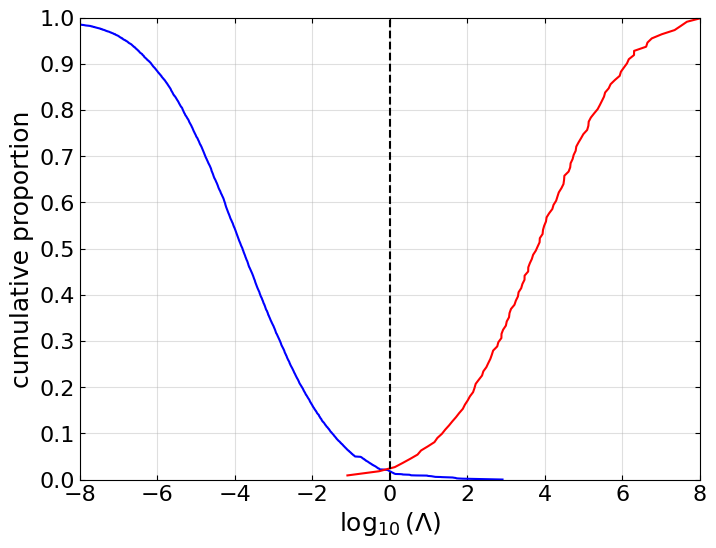

In [7]:
# noVAD-LN tippett plot

from metric import tippett_plot

noVAD_tippett = tippett_plot(ss_llr=noVDA_LN_ss, ds_llr=noVDA_LN_ds,
                             x_range=(-8,8))
print(noVAD_tippett)

Figure(800x600)


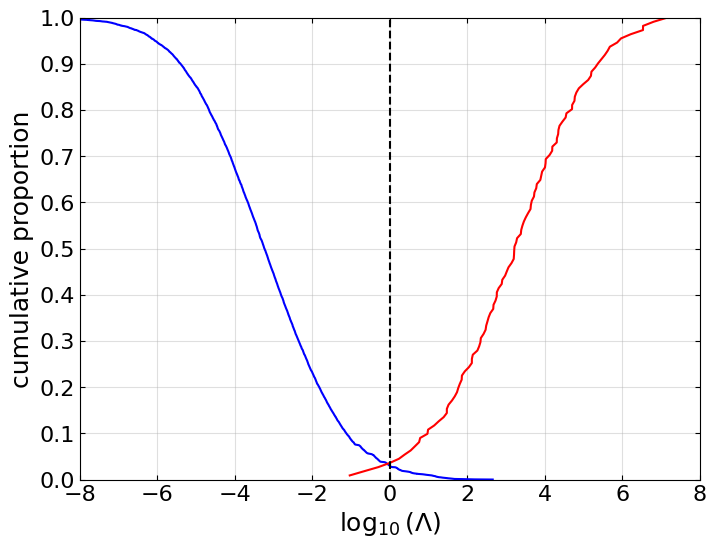

In [8]:
# noVAD-RG tippett plot

from metric import tippett_plot

noVAD_tippett = tippett_plot(ss_llr=noVDA_RG_ss, ds_llr=noVDA_RG_ds,
                             x_range=(-8,8))
print(noVAD_tippett)

Figure(800x600)


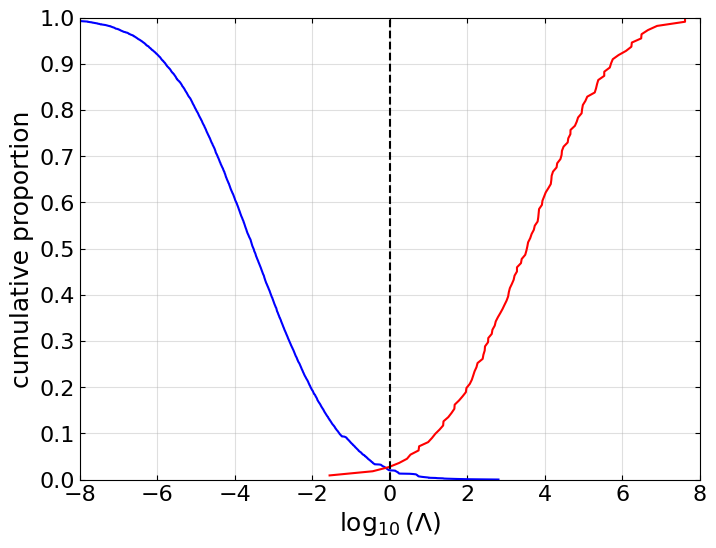

In [9]:
# VADed-LN tippett plot

from metric import tippett_plot

VADed_tippett = tippett_plot(ss_llr=VDAed_LN_ss, ds_llr=VDAed_LN_ds,
                             x_range=(-8,8))
print(VADed_tippett)

Figure(800x600)


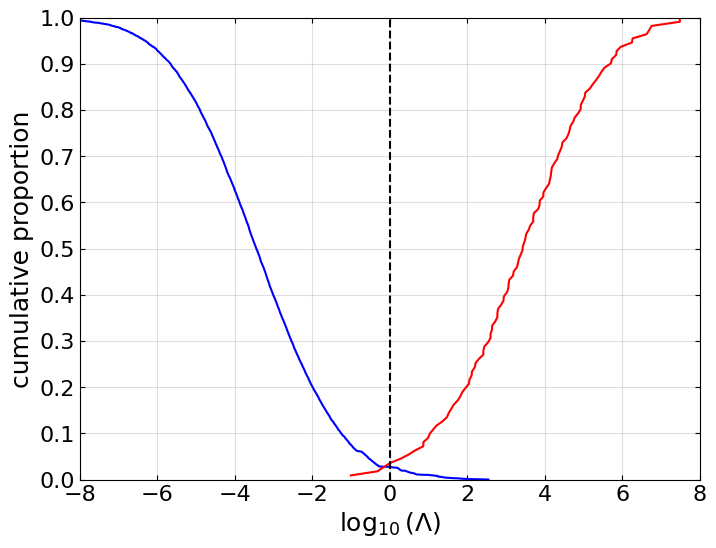

In [10]:
# VADed-RG tippett plot

from metric import tippett_plot

VADed_tippett = tippett_plot(ss_llr=VDAed_RG_ss, ds_llr=VDAed_RG_ds,
                             x_range=(-8,8))
print(VADed_tippett)